In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tpot import TPOTRegressor
import pickle
import logging
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.pipeline import Pipeline

In [19]:
# Ensure you've installed all necessary libraries:
# pip install tpot pandas scikit-learn matplotlib seaborn shap

# Initialize logging for informative output
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')


In [20]:
# Load the dataset with robust error handling
try:
    df = pd.read_csv('testing_data_final.csv')  # Ensure correct path to your dataset
    logging.info("Dataset successfully loaded.")
except FileNotFoundError:
    logging.error("The dataset file was not found.")
    raise
except Exception as e:
    logging.error(f"An unexpected error occurred while loading the dataset: {e}")
    raise

2024-02-24 12:55:23,298 - INFO - Dataset successfully loaded.


In [21]:
# Define features and target variable
features = [
    'sem_present_count', 'sem_absent_count', 'sem_eval_lec_test_1_mark',
    'sem_eval_lab_test_1_mark', 'semester_evaluation_mid_mark',
    'sem_eval_lec_test_2_mark', 'sem_eval_lab_test_2_mark',
    'semester_evaluation_pre_gtu_mark', 'semester_evaluation_internal_mark'
]
target = 'semester_evaluation_gtu_mark'

# Split the dataset into training and test sets
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# Train model with TPOT
tpot = TPOTRegressor(generations=5, population_size=50, verbosity=2, random_state=42)
tpot.fit(X_train_scaled, y_train)
logging.info("Model training completed with TPOT.")

                                                                                                                       
Generation 1 - Current best internal CV score: -3.4285232186271117
                                                                                                                       
Generation 2 - Current best internal CV score: -3.4285232186271117
                                                                                                                       
Generation 3 - Current best internal CV score: -3.2681722207013406
                                                                                                                       
Generation 4 - Current best internal CV score: -3.2681722207013406
                                                                                                                       
Generation 5 - Current best internal CV score: -3.2681722207013406
                                                                 

2024-02-24 13:01:28,387 - INFO - Model training completed with TPOT.


In [29]:
# Evaluate the model's performance
logging.info(f"TPOT R^2 score on test data: {tpot.score(X_test_scaled, y_test)}")

2024-02-24 13:01:54,053 - INFO - TPOT R^2 score on test data: -4.22176086196673


In [30]:
# Export the best model found by TPOT
tpot.export('tpot_best_model.py')

In [120]:
# Save the model to a pickle file
with open('tpot_automl_model.pkl', 'wb') as f:
    pickle.dump(tpot.fitted_pipeline_, f)

In [31]:
# Serialize the scaler object for future use
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
logging.info("Scaler object has been saved.")

2024-02-24 13:01:56,095 - INFO - Scaler object has been saved.


In [118]:

# Proceed with SHAP analysis
try:
    # Review TPOT pipeline steps to ensure no additional transformation is adding features
    print(tpot.fitted_pipeline_)
    
    # Exclude the final estimator and create a transformation pipeline
    transformation_pipeline = Pipeline(tpot.fitted_pipeline_.steps[:-1])

    # Transform X_test using the transformation pipeline
    transformed_X_test = transformation_pipeline.transform(X_test)

    # Confirm the shape of transformed_X_test
    logging.info(f"Transformed test data shape after excluding the final estimator: {transformed_X_test.shape}")

    # Initialize SHAP explainer with the model's predict function and transformed test data
    model_predict_function = tpot.fitted_pipeline_.steps[-1][-1].predict
    explainer = shap.Explainer(model_predict_function, transformed_X_test)
 
    # Generate SHAP values
    shap_values = explainer(transformed_X_test)
    
     # Ensure that the shape of shap_values matches the number of features
    assert shap_values.shape[1] == len(features), "Mismatch in number of SHAP values and features"


    # Check the shape of the SHAP values to confirm they match the expected feature count
    logging.info(f"SHAP values shape: {shap_values.shape}")

    # Visualize SHAP values
    plt.figure()
    shap.summary_plot(shap_values.values, transformed_X_test, feature_names=features)
    plt.title("SHAP Summary Plot for Predicting Final Exam Marks")
    plt.xlabel("SHAP value (impact on model output)")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.savefig('shap_summary_plot.png', dpi=300)  # Save with high resolution
    logging.info("High-resolution SHAP summary plot generated successfully.")
except Exception as e:
    logging.error(f"Error during SHAP analysis: {e}")

AssertionError: The features list does not match the number of columns in the transformed test data

2024-02-24 15:05:15,708 - INFO - Transformed test data shape after excluding the final estimator: (14, 10)


Pipeline(steps=[('stackingestimator',
                 StackingEstimator(estimator=RandomForestRegressor(max_features=0.1,
                                                                   min_samples_leaf=16,
                                                                   min_samples_split=11,
                                                                   random_state=42))),
                ('adaboostregressor',
                 AdaBoostRegressor(learning_rate=0.5, loss='square',
                                   n_estimators=100, random_state=42))])


2024-02-24 15:05:16,176 - INFO - SHAP values shape: (14, 10)


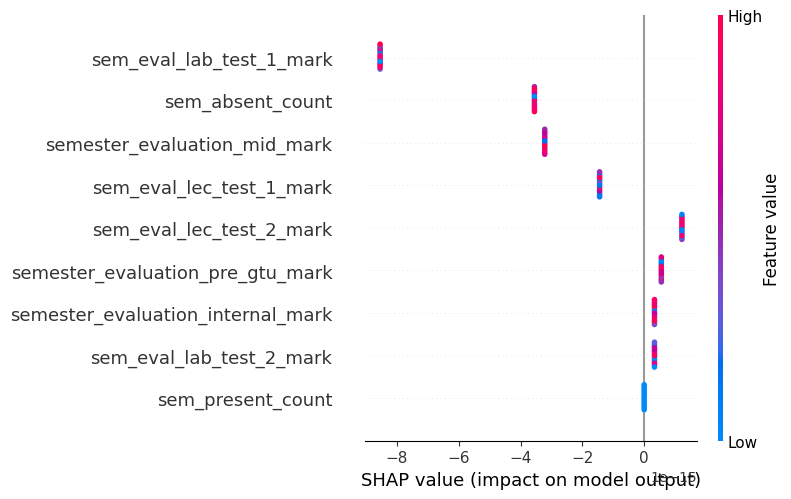

2024-02-24 15:05:16,357 - INFO - SHAP summary plot generated successfully.


<Figure size 640x480 with 0 Axes>

In [128]:
# Proceed with SHAP analysis
try:
    # Review TPOT pipeline steps to ensure no additional transformation is adding features
    print(tpot.fitted_pipeline_)
    
    # Exclude the final estimator and create a transformation pipeline
    transformation_pipeline = Pipeline(tpot.fitted_pipeline_.steps[:-1])

    # Transform X_test using the transformation pipeline
    transformed_X_test = transformation_pipeline.transform(X_test)

    # Confirm the shape of transformed_X_test
    logging.info(f"Transformed test data shape after excluding the final estimator: {transformed_X_test.shape}")

    # Initialize SHAP explainer with the model's predict function and transformed test data
    model_predict_function = tpot.fitted_pipeline_.steps[-1][-1].predict
    explainer = shap.Explainer(model_predict_function, transformed_X_test)

    # Generate SHAP values
    shap_values = explainer(transformed_X_test)

    # Check the shape of the SHAP values to confirm they match the expected feature count
    logging.info(f"SHAP values shape: {shap_values.shape}")

    # Visualize SHAP values
    plt.figure()
    shap.summary_plot(shap_values.values[:, :9], transformed_X_test[:, :9], feature_names=features)
    plt.savefig('shap_summary_plot.png')
    logging.info("SHAP summary plot generated successfully.")
    # Assuming that `model` is your trained model
   

except Exception as e:
    logging.error(f"Error during SHAP analysis: {e}")

In [131]:

# Assuming that `model` is your trained model
# Create a sample dataset with 10 features
X_sample = np.random.rand(1, 10)

explainer = shap.KernelExplainer(model.predict, X_sample)

with open('shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

In [ ]:
with open('tpot_automl_model.pkl', 'wb') as f:
    pickle.dump(tpot.fitted_pipeline_, f)

2024-02-24 15:03:57,924 - ERROR - Error during SHAP analysis: list index out of range


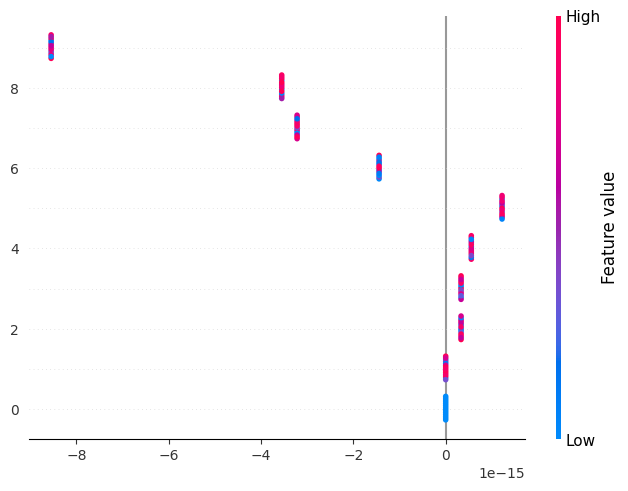

In [124]:
# Prepare for SHAP analysis
try:
    # Create a pipeline with all preprocessing steps, excluding the final estimator
    preprocessing_pipeline = Pipeline(tpot.fitted_pipeline_.steps[:-1])

    # Transform the test data using only the preprocessing steps
    transformed_X_test = preprocessing_pipeline.transform(X_test)

    # The final estimator is the one used for predictions
    final_estimator = tpot.fitted_pipeline_.steps[-1][1]

    # We need to make sure that we use the same number of features that the final estimator was trained on
    # Since we are unsure about the preprocessing steps adding extra features, we will not slice the test data
    # Instead, we generate SHAP values for the entire transformed test data set
    explainer = shap.Explainer(final_estimator.predict, transformed_X_test)
    shap_values = explainer(transformed_X_test)

       # Define feature names based on your dataset
    
    # Plot SHAP values
    plt.figure(figsize=(20, 20))  # Adjust the figure size as needed
    shap.summary_plot(
        shap_values.values, 
        transformed_X_test, 
         feature_names = [
        'sem_present_count', 'sem_absent_count', 'sem_eval_lec_test_1_mark',
        'sem_eval_lab_test_1_mark', 'semester_evaluation_mid_mark',
        'sem_eval_lec_test_2_mark', 'sem_eval_lab_test_2_mark',
        'semester_evaluation_pre_gtu_mark', 'semester_evaluation_internal_mark'
    ] # Replace with your actual feature names
    )

    # The feature_names should correspond to the transformed features
    # If the preprocessing steps added features, this list needs to be extended accordingly
    #feature_names = ['feature_' + str(i) for i in range(transformed_X_test.shape[1])]

    plt.title("SHAP Summary Plot for Predicting Final Exam Marks")
    plt.xlabel("SHAP value (impact on model output)")
    plt.ylabel("Features")
    plt.tight_layout()  # Adjust the layout to prevent clipping of labels
    plt.savefig('shap_summary_plot_with_feature_names.png')
    logging.info("SHAP summary plot with actual feature names generated successfully.")
except Exception as e:
    logging.error(f"Error during SHAP analysis: {e}")